# 06b · Analgesic use by therapeutic class (no aspirin)

Aspirin dominated notebook 06 and is typically cardio-preventive, not pain management. Here we re-run the analysis by class: opioid / NSAID / neuropathic / acetaminophen / muscle-relaxant / topical. Compare pre-anchor vs post-anchor exposure by DBS arm.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({ library(dplyr); library(tidyr); library(ggplot2); library(lubridate); library(stringr); library(purrr) })

path_conmed <- file.path(PROJECT_ROOT, "Propensity score DBS sleep", "Data I need to merge",
                        "Concomitant_Medication_Log_04Nov2024.csv")
cm <- readr::read_csv(path_conmed, show_col_types = FALSE) %>%
  dplyr::mutate(PATNO = as.integer(PATNO), CMTRT = toupper(CMTRT),
                STARTDT = suppressWarnings(lubridate::my(STARTDT)),
                STOPDT  = suppressWarnings(lubridate::my(STOPDT)))

# Flag each row with its class
for (cls in names(ANALGESIC_CLASSES)) {
  rx <- toupper(paste(ANALGESIC_CLASSES[[cls]], collapse = "|"))
  cm[[cls]] <- stringr::str_detect(dplyr::coalesce(cm$CMTRT, ""), rx)
}
cat("Rows matching each class:\n")
print(sapply(names(ANALGESIC_CLASSES), function(k) sum(cm[[k]], na.rm = TRUE)))

Rows matching each class:


       opioid         nsaid   neuropathic acetaminophen  muscle_relax 
          278          1109           813           431           147 
      topical 
           21 


In [2]:
rel <- load_full_ppmi_rel_patient_anchor()
anchors <- rel %>% dplyr::distinct(PATNO, will_receive_dbs, anchor_date)

# For each class, compute pre/post presence per patient
window_flag <- function(cm_sub, lo, hi) {
  cm_sub %>% dplyr::inner_join(anchors, by = "PATNO") %>%
    dplyr::mutate(
      start_rel = as.numeric(difftime(STARTDT, anchor_date, units = "days")) / DAYS_PER_MONTH,
      stop_rel  = as.numeric(difftime(dplyr::coalesce(STOPDT, as.Date("2099-12-31")),
                                      anchor_date, units = "days")) / DAYS_PER_MONTH) %>%
    dplyr::filter(!is.na(start_rel), start_rel <= hi, stop_rel >= lo) %>%
    dplyr::distinct(PATNO) %>% dplyr::pull(PATNO)
}

class_res <- purrr::map_dfr(names(ANALGESIC_CLASSES), function(cls) {
  cm_cls <- cm %>% dplyr::filter(.data[[cls]])
  pre  <- window_flag(cm_cls, -12, 0)
  post <- window_flag(cm_cls,  6, 18)
  anchors %>% dplyr::mutate(
    any_pre = PATNO %in% pre, any_post = PATNO %in% post,
    class = cls
  )
})

summ <- class_res %>% dplyr::group_by(class, will_receive_dbs) %>%
  dplyr::summarise(
    n = dplyr::n(),
    pct_pre  = mean(any_pre),
    pct_post = mean(any_post),
    pct_new  = mean(!any_pre &  any_post),
    pct_stop = mean( any_pre & !any_post),
    .groups = "drop"
  )
print(summ)
save_table(summ, "analgesic_class_by_arm")

# A tibble: 12 × 7
   class         will_receive_dbs     n pct_pre pct_post  pct_new pct_stop
   <chr>         <lgl>            <int>   <dbl>    <dbl>    <dbl>    <dbl>
 1 acetaminophen FALSE             1379 0.00798  0.00943 0.00145         0
 2 acetaminophen TRUE               105 0.0286   0.0286  0               0
 3 muscle_relax  FALSE             1379 0.00145  0.00218 0.000725        0
 4 muscle_relax  TRUE               105 0        0       0               0
 5 neuropathic   FALSE             1379 0.00653  0.00943 0.00290         0
 6 neuropathic   TRUE               105 0        0       0               0
 7 nsaid         FALSE             1379 0.0268   0.0312  0.00435         0
 8 nsaid         TRUE               105 0.0667   0.0857  0.0190          0
 9 opioid        FALSE             1379 0.00363  0.00363 0               0
10 opioid        TRUE               105 0.00952  0.00952 0               0
11 topical       FALSE             1379 0        0       0               0
12 top

In [3]:
# Chi-square per class for pre-anchor exposure (baseline imbalance)
chi <- purrr::map_dfr(names(ANALGESIC_CLASSES), function(cls) {
  d <- class_res %>% dplyr::filter(class == cls)
  tab <- table(d$will_receive_dbs, d$any_pre)
  if (any(dim(tab) < 2)) return(tibble::tibble(class = cls, test = "pre",
                                               p = NA, or = NA))
  f <- stats::fisher.test(tab)
  tibble::tibble(class = cls, test = "pre",
                 p = f$p.value, or = as.numeric(f$estimate))
})
print(chi)
save_table(chi, "analgesic_class_fisher")

# A tibble: 6 × 4
  class         test        p    or
  <chr>         <chr>   <dbl> <dbl>
1 opioid        pre    0.357   2.64
2 nsaid         pre    0.0315  2.59
3 neuropathic   pre    1       0   
4 acetaminophen pre    0.0707  3.65
5 muscle_relax  pre    1       0   
6 topical       pre   NA      NA   


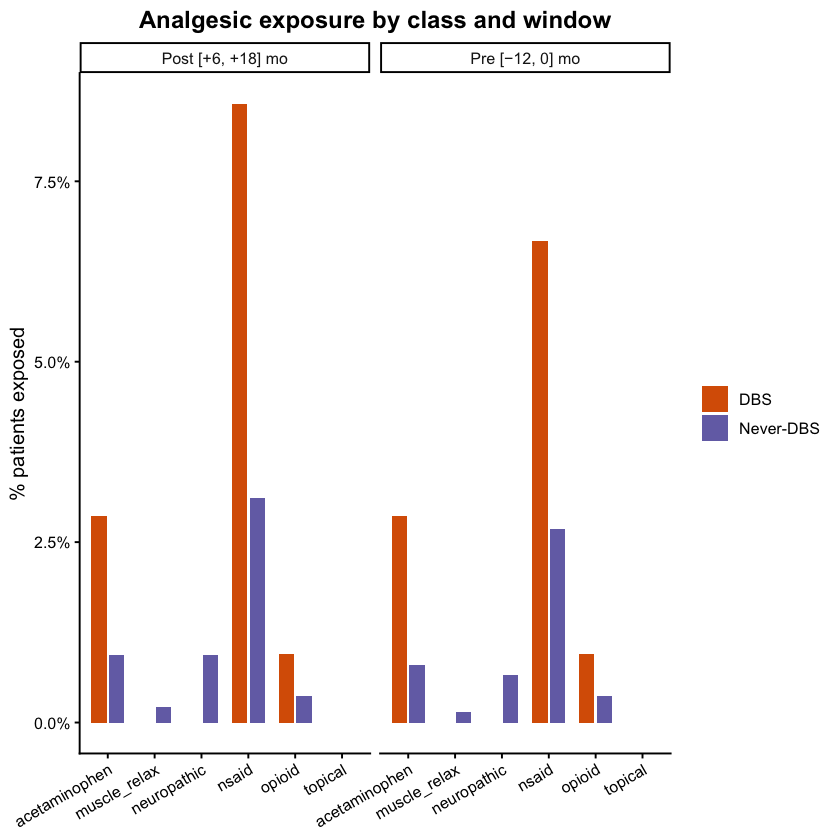

In [4]:
pl <- summ %>% tidyr::pivot_longer(c(pct_pre, pct_post), names_to = "window", values_to = "prop") %>%
  dplyr::mutate(window = dplyr::recode(window, pct_pre = "Pre [−12, 0] mo", pct_post = "Post [+6, +18] mo"),
                arm = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS"))
p_cls <- ggplot(pl, aes(x = class, y = prop, fill = arm)) +
  geom_col(position = position_dodge(0.75), width = 0.65) +
  facet_wrap(~ window) +
  scale_y_continuous("% patients exposed", labels = scales::percent_format()) +
  scale_fill_manual(values = c(`DBS` = "#d95f02", `Never-DBS` = "#7570b3"), name = NULL) +
  labs(title = "Analgesic exposure by class and window", x = NULL) +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        axis.text.x = element_text(angle = 30, hjust = 1))
p_cls
save_fig(p_cls, "Fig21_analgesic_by_class", width = 9, height = 4.5)